# Imports

In [2]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import pickle

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/andonians/random-linear-regression/train.csv
/kaggle/input/datasets/andonians/random-linear-regression/test.csv


# Data Loading

In [8]:
train_data=pd.read_csv('/kaggle/input/datasets/andonians/random-linear-regression/train.csv')
train_data.head()

,x,y
0,24.0,21.549452
1,50.0,47.464463
2,15.0,17.218656
3,38.0,36.586398
4,87.0,87.288984


plot the data here

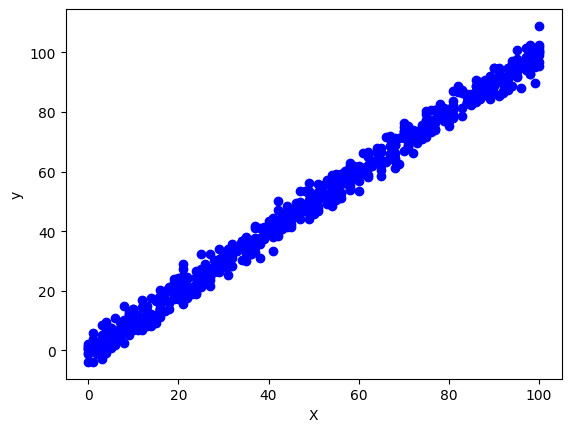

In [9]:
X=train_data[['x']]
y=train_data[['y']]
plt.scatter(X,y,color='blue',label='Random Graph')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

# Data Preprocessing

# Standardize the data

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

train_data=train_data.fillna(train_data.mean(numeric_only=True))


X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


# Why Use Standardization in Machine Learning?

When different features in a dataset have very different ranges, the model prioritises the feature(s) with higher values, and may become biased. Therefore, standardization makes the values comparable, and may lead to unbiased learning.  

# How to Standardize Data


We subtract the mean from each value, and divide it by the standard deviation. This is done through StandardScaler

## Reshaping data for the correct shape for the model

why cant we make the model without reshaping?

ML Models require input in the form of 2D, and not 1D, so that they can differentiate between samples and features

# Model Implementation

# Linear Regression Model

Linear regression is a fundamental model in machine learning used for predicting a continuous output variable based on input features. The model function for linear regression is represented as:

$$f_{w,b}(x) = wx + b$$

In this equation, $f_{w,b}(x)$ represents the predicted output, $w$ is the weight parameter, $b$ is the bias parameter, and $x$ is the input feature.

## Model Training

To train a linear regression model, we aim to find the best values for the parameters $(w, b)$ that best fit our dataset.

### Forward Pass

The forward pass is a step where we compute the linear regression output for the input data $X$ using the current weights and biases. It's essentially applying our model to the input data.

### Cost Function

The cost function is used to measure how well our model is performing. It quantifies the difference between the predicted values and the actual values in our dataset. The cost function is defined as:

$$J(w,b) = \frac{1}{2m} \sum_{i=1}^{m}(f_{w,b}(x^{(i)}) - y^{(i)})^2$$

Here, $J(w, b)$ is the cost, $m$ is the number of training examples, $x^{(i)}$ is the input data for the $i$-th example, $y^{(i)}$ is the actual output for the $i$-th example, and $w$ and $b$ are the weight and bias parameters, respectively.

### Backward Pass (Gradient Computation)

The backward pass computes the gradients of the cost function with respect to the weights and biases. These gradients are crucial for updating the model parameters during training. The gradient formulas are as follows:

$$
\frac{\partial J(w,b)}{\partial b} = \frac{1}{m} \sum_{i=0}^{m-1} (f_{w,b}(X^{(i)}) - y^{(i)})
$$

$$
\frac{\partial J(w,b)}{\partial w} = \frac{1}{m} \sum_{i=0}^{m-1} (f_{w,b}(X^{(i)}) - y^{(i)})X^{(i)}
$$

## Training Process

The training process involves iteratively updating the weights and biases to minimize the cost function. This is typically done through an optimization algorithm like gradient descent. The update equations for parameters are:

$$w \leftarrow w - \alpha \frac{\partial J}{\partial w}$$

$$b \leftarrow b - \alpha \frac{\partial J}{\partial b}$$

Here, $\alpha$ represents the learning rate, which controls the step size during parameter updates.

By iteratively performing the forward pass, computing the cost, performing the backward pass, and updating the parameters, the model learns to make better predictions and fit the data.


In [29]:
class LinearRegression:
    
    def __init__(self,lr=0.01):
        self.lr=lr
        self.w=None
        self.b=None
        #stores learning rate, weights(w), and biases(b)
        
    def initialize_parameters(self,n_features):
        self.w = np.zeros((n_features, 1))
        self.b = 0
        

    def forward(self,X):
        return np.dot(X,self.w) + self.b
        #y=mx+b, where m=w(weights), b=biases

    def compute_cost(self,y,y_pred):
        m=y.shape[0]
        cost=(1/(2*m)) * np.sum((y_pred-y)**2)
        return cost

    def backward(self,X,y,y_pred):
        m=X.shape[0]
        dw=(1/m) * np.dot(X.T,(y_pred-y))
        db=(1/m) * np.sum(y_pred-y)
        return dw,db

    def fit(self, X, y, iterations, plot_cost=True):
        y=y.values.reshape(-1,1)
        self.initialize_parameters(X.shape[1])

        for i in range(iterations):
            y_pred=self.forward(X)
            cost=self.compute_cost(y,y_pred)
            dw,db=self.backward(X,y,y_pred)
            
            self.w-=self.lr*dw
            self.b-=self.lr*db

        if i % 100 == 0:
            print(f"Iteration {i}, Cost: {cost}")
            
    def predict(self, X):
        return self.forward(X)
        
    import pickle
    def save_model(self, filename=None):
        with open(filename,'wb') as f:
            pickle.dump(self,f)
    
    @classmethod
    def load_model(cls, filename):
        import pickle
        with open('filename',rb) as f:
            return pickle.load(f)

   

In [45]:
lr = LinearRegression(lr=0.001)
lr.fit(X_train, y_train,iterations=1000)

In [46]:
lr.save_model('model.pkl')

# Evaluation



### 1. Mean Squared Error (MSE)

**Formula:**
$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_{\text{true}_i} - y_{\text{pred}_i})^2
$$

**Description:**
 - fill this

**Interpretation:**
-  fill this

### 2. Root Mean Squared Error (RMSE)

**Formula:**
$$
\text{RMSE} = \sqrt{\text{MSE}}
$$

**Description:**
- fill this
**Interpretation:**
- fill this


### 3. R-squared ($R^2$)

**Formula:**
$$
R^2 = 1 - \frac{\text{SSR}}{\text{SST}}
$$

**Description:**
 fill this 

**Interpretation:**
 fill this


In [47]:
class RegressionMetrics:
    @staticmethod
    def mean_squared_error(y, y_pred):
        return np.mean((y-y_pred)**2)
        
    @staticmethod
    def root_mean_squared_error(y, y_pred):
        mse=np.mean((y-y_pred)**2)
        return np.sqrt(mse)
        
    @staticmethod
    def r_squared(y, y_pred):
        y=y.to_numpy().reshape(-1,1)
        y_pred=y_pred.reshape(-1,1)
        ssr=np.sum((y-y_pred)**2)
        sst=np.sum((y-np.mean(y))**2)
        return 1-(ssr/sst)


        

        

In [1]:
y_pred = lr.predict(X_test)
mse_value = RegressionMetrics.mean_squared_error(y_test, y_pred)
rmse_value = RegressionMetrics.root_mean_squared_error(y_test, y_pred)
r_squared_value = RegressionMetrics.r_squared(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse_value}")
print(f"Root Mean Squared Error (RMSE): {rmse_value}")
print(f"R-squared (Coefficient of Determination): {r_squared_value}")

NameError: name 'lr' is not defined